# Project 3 — Credit Card Fraud Detection

## Part 1 — EDA and Data Pre-Processing

This notebook adapts the course EDA/preprocessing workflow to the Kaggle **Credit Card Fraud Detection** dataset.

**Target:** `Class`  
- `0` = legitimate transaction
- `1` = fraudulent transaction

**Required preprocessing for this project:**
1. Load `creditcard.csv` from `backend/data/raw/creditcard.csv` or `data/raw/creditcard.csv`.
2. Drop `Time`.
3. Split data using stratification on `Class`.
4. Fit `StandardScaler` on the training `Amount` column only.
5. Transform `Amount` in train/test.
6. Export files required by Docker/H2O/MLflow/Streamlit.


## 1. Initial setup


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


## 2. Project paths

The same notebook can run either from the project root or from inside the `backend/` folder.


In [2]:
from pathlib import Path

cwd = Path.cwd()

if (cwd / "backend" / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "backend" / "data").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATA_DIR = PROJECT_ROOT / "backend" / "data"

RAW_PATH = DATA_DIR / "raw" / "creditcard.csv"
PROCESSED_DIR = DATA_DIR / "processed"
TRAIN_PATH = PROCESSED_DIR / "train.csv"
TEST_PATH = PROCESSED_DIR / "test.csv"
SAMPLE_TEST_PATH = DATA_DIR / "sample_test.csv"
SAMPLE_TEST_LABELED_PATH = DATA_DIR / "sample_test_labeled.csv"

print("Current folder:", cwd)
print("Project root:", PROJECT_ROOT)
print("Data folder:", DATA_DIR)
print("Raw path:", RAW_PATH)
print("Raw file exists:", RAW_PATH.exists())

Current folder: c:\Users\barba\Documents\AI Deployment\6. Final_ProjectAI\FP_AI\notebooks
Project root: c:\Users\barba\Documents\AI Deployment\6. Final_ProjectAI\FP_AI
Data folder: c:\Users\barba\Documents\AI Deployment\6. Final_ProjectAI\FP_AI\backend\data
Raw path: c:\Users\barba\Documents\AI Deployment\6. Final_ProjectAI\FP_AI\backend\data\raw\creditcard.csv
Raw file exists: True


## 3. Load raw dataset


In [3]:
df_raw = pd.read_csv(RAW_PATH)
print(df_raw.shape)
df_raw.head()


(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 4. Basic EDA


In [4]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
df_raw.describe().T


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [6]:
class_counts = df_raw["Class"].value_counts().sort_index()
class_percent = (df_raw["Class"].value_counts(normalize=True).sort_index() * 100).round(4)

summary = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percent
})
summary.index = ["Legitimate (0)", "Fraud (1)"]
summary


,count,percentage
Legitimate (0),284315,99.8273
Fraud (1),492,0.1727


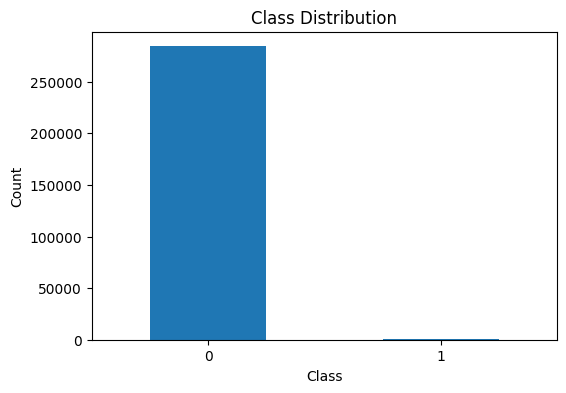

In [7]:
ax = class_counts.plot(kind="bar", figsize=(6, 4), title="Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.show()


In [8]:
amount_summary = df_raw.groupby("Class")["Amount"].describe()
amount_summary


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


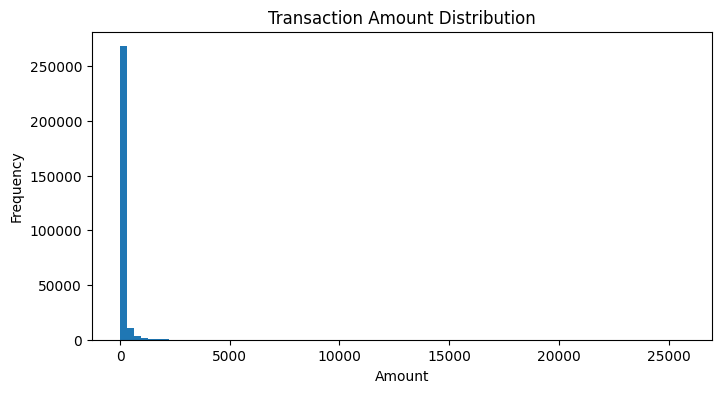

In [9]:
ax = df_raw["Amount"].plot(kind="hist", bins=80, figsize=(8, 4), title="Transaction Amount Distribution")
ax.set_xlabel("Amount")
plt.show()


## 5. Preprocessing

For this dataset, `V1` to `V28` are already PCA-transformed numeric features. There is no categorical encoding needed.

We only need to:
- drop `Time`;
- keep `Class` as the target;
- split train/test with stratification;
- scale `Amount` using a scaler fitted on the training set only.


In [10]:
df = df_raw.copy()

if "Time" in df.columns:
    df = df.drop(columns=["Time"])

if "Class" not in df.columns:
    raise ValueError("Expected target column 'Class' was not found.")

print(df.shape)
df.head()


(284807, 30)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Train/test split


In [11]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["Class"]
)

train_df = train_df.copy()
test_df = test_df.copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train class counts:", train_df["Class"].value_counts().to_dict())
print("Test class counts:", test_df["Class"].value_counts().to_dict())


Train shape: (227845, 30)
Test shape: (56962, 30)
Train class counts: {0: 227451, 1: 394}
Test class counts: {0: 56864, 1: 98}


### Scale `Amount`

Important MLOps detail: the scaler is fitted on the **training data only** to avoid data leakage.


In [12]:
scaler = StandardScaler()
train_df["Amount"] = scaler.fit_transform(train_df[["Amount"]])
test_df["Amount"] = scaler.transform(test_df[["Amount"]])

print("Train Amount mean:", round(train_df["Amount"].mean(), 6))
print("Train Amount std:", round(train_df["Amount"].std(), 6))
print("Test Amount mean:", round(test_df["Amount"].mean(), 6))
print("Test Amount std:", round(test_df["Amount"].std(), 6))


Train Amount mean: 0.0
Train Amount std: 1.000002
Test Amount mean: 0.003456
Test Amount std: 0.987933


## 6. Create Streamlit sample files

The normal test set is extremely imbalanced, so this notebook creates a small **demo sample** with both classes visible.

- `sample_test.csv` excludes `Class` and is used for prediction only.
- `sample_test_labeled.csv` includes `Class` and allows the frontend to show metrics and a confusion matrix.


In [13]:
n_legit = min(180, int((test_df["Class"] == 0).sum()))
n_fraud = min(20, int((test_df["Class"] == 1).sum()))

legit = test_df[test_df["Class"] == 0].sample(n=n_legit, random_state=42)
fraud = test_df[test_df["Class"] == 1].sample(n=n_fraud, random_state=42)

sample_labeled = (
    pd.concat([legit, fraud])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

sample_unlabeled = sample_labeled.drop(columns=["Class"])

print("Sample labeled shape:", sample_labeled.shape)
print("Sample class counts:", sample_labeled["Class"].value_counts().to_dict())
sample_labeled.head()


Sample labeled shape: (200, 30)
Sample class counts: {0: 180, 1: 20}


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.152466,-0.350442,1.530463,0.459703,0.472315,-0.242138,1.344712,-0.429407,-0.603544,0.280028,1.927642,0.327465,-0.601039,0.257552,0.801202,-0.393039,-0.196449,-0.579418,0.787314,0.171677,-0.403237,-0.912994,0.627093,0.165803,-0.704149,-0.146309,-0.303466,-0.288624,0.342865,0
1,-0.464374,-0.202580,2.092739,-2.728698,-0.546591,-0.232174,-0.125060,-0.253106,-2.189879,1.005982,-1.109273,-0.760951,2.139546,-1.252894,0.184569,0.077183,-0.341729,0.446471,-0.656460,0.042412,-0.144450,0.264018,-0.442479,-0.435246,0.558927,-0.151099,0.155027,-0.098123,-0.304625,0
2,1.203377,0.149740,0.603745,0.560316,-0.591890,-0.804040,-0.090672,-0.026808,-0.109545,0.126175,1.531528,0.707219,-0.591732,0.604515,0.402650,0.476427,-0.554545,-0.017279,0.099045,-0.140207,-0.201649,-0.658440,0.159175,0.508801,0.133655,0.067154,-0.037652,0.009137,-0.346544,0
3,-0.329033,1.490168,1.791169,2.911077,0.154034,0.288919,0.340845,-0.713450,-1.338410,0.700305,-0.762903,0.513061,1.339296,-0.464544,-1.012586,1.099819,-0.891862,-0.609729,-2.035701,-0.339728,0.685965,-0.460296,0.328045,0.328234,-0.823394,-0.476371,0.141239,0.079950,-0.271960,0
4,-0.601572,0.622922,-0.981547,-0.786905,0.766944,-0.201695,0.247384,0.613575,0.162620,-0.046616,-0.270383,-0.010916,-1.490030,0.789877,-1.114286,0.306856,-0.547872,0.098484,0.380219,-0.087560,-0.196287,-0.532710,0.284890,-0.011988,-0.574292,0.168192,0.250125,0.071959,-0.303469,0


## 7. Export processed datasets


In [14]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
(DATA_DIR / "raw").mkdir(parents=True, exist_ok=True)

train_df.to_csv(TRAIN_PATH, index=False)
test_df.to_csv(TEST_PATH, index=False)
sample_unlabeled.to_csv(SAMPLE_TEST_PATH, index=False)
sample_labeled.to_csv(SAMPLE_TEST_LABELED_PATH, index=False)

print("Saved:")
print(TRAIN_PATH)
print(TEST_PATH)
print(SAMPLE_TEST_PATH)
print(SAMPLE_TEST_LABELED_PATH)


Saved:
c:\Users\barba\Documents\AI Deployment\6. Final_ProjectAI\FP_AI\backend\data\processed\train.csv
c:\Users\barba\Documents\AI Deployment\6. Final_ProjectAI\FP_AI\backend\data\processed\test.csv
c:\Users\barba\Documents\AI Deployment\6. Final_ProjectAI\FP_AI\backend\data\sample_test.csv
c:\Users\barba\Documents\AI Deployment\6. Final_ProjectAI\FP_AI\backend\data\sample_test_labeled.csv


## 8. Final schema check

The Docker trainer expects `data/processed/train.csv` with target `Class`. The Streamlit frontend expects `sample_test.csv` without `Class` or `sample_test_labeled.csv` with `Class`.


In [15]:
print("train.csv columns:", len(train_df.columns))
print("sample_test.csv has Class:", "Class" in sample_unlabeled.columns)
print("sample_test_labeled.csv has Class:", "Class" in sample_labeled.columns)

assert "Time" not in train_df.columns
assert "Class" in train_df.columns
assert "Class" not in sample_unlabeled.columns
assert "Class" in sample_labeled.columns

print("All checks passed.")


train.csv columns: 30
sample_test.csv has Class: False
sample_test_labeled.csv has Class: True
All checks passed.
